# The Autonomous Compliance Sentinel
## Goal 2 - **Version 2** (see ‘Update in Version 2’ at the end of this notebook)

| Project | The Autonomous Compliance Sentinel |
| --- | --- |
| Modul | Responsible AI and Data Ethics |
| Authors | Group 2: Singh, Vikrant and Müller, Kay |

**Running the notebook.** All data now loads through the tested `sentinel` package

In [1]:
import os, sys
# XGBoost and PyTorch (via sentence-transformers in Part 4) each load their own
# OpenMP runtime; on macOS that clashes and segfaults the kernel. Capping OpenMP
# to one thread before those imports avoids the crash. Must stay at the very top.
os.environ["OMP_NUM_THREADS"] = "1"
sys.path.insert(0, "/")   # folder for the sentinel package and CSV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    RocCurveDisplay, roc_curve, precision_recall_curve,
)

from langchain_huggingface import HuggingFaceEmbeddings   # Part 4 (BGE experiment)

import sentinel as S                      # tested Goal-2 pipeline
from sentinel import metrics as MET

sns.set_theme(style="whitegrid", context="talk")
print("sentinel version:", S.__version__)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sentinel version: 1.0


---

# Part 1: XGBoost model (TF-IDF) - Preliminary assessment

*The alternative classifier: TF-IDF + XGBoost, analysed with the Standard /
Risk / Fairness framework. It uses the same sentinel data and split as the
primary model, so the numbers are comparable to the Logistic Regression.*


## Section 1: Standard Framework

### What is the Standard Framework?

The Standard Framework in this project is built on two pillars:
- The **RAI-01 to RAI-09 policy catalogue** (defined in Goal 1), which is grounded in the IBM AI Trust pillars and the EU AI Act.
- A **baseline model evaluation** using standard classification metrics.

The standard framework answers one question: *Is the model any good at detecting red flags?*

We measure this using the following metrics:
- **Precision** : of everything we flagged, how much was actually a violation?
- **Recall** : of all real violations, how many did we catch? (Most important for this project)
- **F1 Score** : balance between precision and recall.
- **ROC-AUC** : how well the model separates red flags from compliant proposals across all thresholds.

### Why recall is the most important metric here:
- A **False Negative** (missed violation) means a real policy breach goes undetected and potentially goes live.
- A **False Positive** (wrong flag) means a reviewer checks a clean proposal and clears it. Annoying but harmless.
- Missing a violation costs more than a false alarm, so we prioritise recall over precision.

### What we build here:
- Load and prepare the data.
- Handle class imbalance (667 compliant vs 333 red flag).
- Train a TF-IDF + XGBoost classifier.
- Evaluate using confusion matrix, ROC curve, precision-recall curve and classification report.


In [2]:
df = S.load_proposals()   # tested sentinel loader (same CSV)
df.dtypes

proposal_id        str
project            str
issue_type         str
ai_method          str
description        str
red_flags          str
n_red_flags      int64
is_compliant     int64
grounded_flag    int64
label              str
word_count       int64
y                int64
dtype: object

### For the following, keep in mind that:
- I am reverting the 1 values to 0 and 0 values to 1.
- Because:
    - sklearn evaluation metric function performs significantly better when what they are trying to predict has a value 1.
    - Eval metrics have a hidden rule that 1 is the thing they are trynna catch. (What they are trying to predict.)
- Before flipping: 
    - 0 : Red Flag
    - 1 : Compliant
- After flipping:
    - 0 : Compliant.
    - 1 : Red Flag


In [3]:
y = 1 - df["is_compliant"] # Target
X_text = df["description"] # The Feature we will be using

### Train Test Split:
- When train_test_split splits your 1000 proposals into 800 training and 200 test, it does it randomly.
- stratify=y will: 
    - It looks at y <--> your list of 0s and 1s. 
    - Counts the ratio of each class, and then forces the split to preserve that exact ratio in both piles.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

### TF-IDF Vectorizer:
- X_train_vec contains a vocabulary built up (``fit``) using important words from the X_train split (800 texts) and then each text is converted to vectors (``transform``).
- X_test_vec uses the information about the vocabulary from the aforementioned pointer and just builds vectors for all the texts in X_text.

In [5]:
vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
# The test set MUST BE UNSEEN :- Hence we only transform it.
X_test_vec = vectorizer.transform(X_test)

### The two classes separated and summed (scale_pos_weight):
- Here we calculate the class distribution in the y_train set.
- y_train is the set which contains the class counts on which ``THE MODEL ACTUALLY TRAINED ON``.

In [6]:
neg=(y_train==0).sum()
pos=(y_train==1).sum()
scale_pos_weight=neg/pos

### Printing the actual counts for class imbalance:

In [7]:
print(f"Compliant (train): {neg}  |  Red Flag (train): {pos}")
print(f"Imbalance ratio: {round(neg/pos, 2)} : 1")
print(f"scale_pos_weight: {round(scale_pos_weight, 3)}")

Compliant (train): 534  |  Red Flag (train): 266
Imbalance ratio: 2.01 : 1
scale_pos_weight: 2.008


### Model initialization with :
- n_estimators=200 (Number of decesion trees the model will build in sequence.)
    - Why 200, because that is the standard starting point.
- max_depth=4 (Maximum number of levels to which the yes or no can go till in a branch)
    - Why 4, consider it as a standard start point too.
    - You keep it too less, the model won't learn anything meaningful.
    - You keep it too high, model starts to memorize the dataset.
- learning_rate=0.1 (A scaling factor that controls how much each tree's correction is allowed to change the overall prediction.)
    - After each tree makes its correction, that correction gets multiplied by the learning rate before being added to the running prediction:
        - ````new prediction=old prediction+0.1×tree’s correction````
>``NOTE`` : 
- n_estimators and learning_rate go hand in hand such that:
    - Lower learning rate = need more trees
    - Higher learning rate = need fewer trees
- eval_metric="logloss" (The internal scoring rule XGBoost uses during training to measure how wrong the current predictions are after each tree is added)
    - Model says 95% Red Flag, actually IS Red Flag → tiny penalty (good, confident, correct)
    - Model says 95% Red Flag, actually is Compliant → huge penalty (bad, confident, wrong)
    - Model says 52% Red Flag, actually IS Red Flag → medium penalty (correct but not confident)
- random_state=42 (Reproducability)
- scale_pos_weight=scale_pos_weight ()
    - The imbalance correction factor for training.
    - On the left hand side scale_pos_weight is a parameter which XGBoost expects.

In [8]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
)

### Fit the train sets on the model:

In [9]:
model.fit(X_train_vec, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### pred and proba:
- `model.predict()` : 
    - model.predict(X_test_vec) feeds all 200 test proposals through all 200 trees one by one.
    -  Each tree adds its small correction. 
    - The running total becomes a raw score. 
    - That raw score goes through the sigmoid function to become a probability. 
    - Then the probability goes through the decision threshold of 0.5:
        - probability ≥ 0.5 → output 1 (Red Flag)
        - probability < 0.5 → output 0 (Compliant)
- `model.predict_proba()` : 
    - It does the exact same internal calculation as model.predict().
    - Then feeds proposals through all 200 trees, gets raw scores, applies sigmoid. 
    - But it stops before the 0.5 threshold step. 
    - Instead of giving you a hard 0 or 1, it gives you the actual probability.
    - It creates 2 columns for n number of rows in our case 200 with probabilities for both classes.

### NOTE : 
>> ``Also keep in mind that confusion matrix can not work with probabilities so you need hard decesions (model.predict()).``
>> ``roc_auc_score can not work with hard numbers so you need probabilities (model.predict_proba())`` 

In [10]:
y_pred = model.predict(X_test_vec) # Creates a list of hard numbers 0 and 1 for our two classes. This is the default behavior of the predict method.
y_proba = model.predict_proba(X_test_vec)[:, 1] # Used to fetch 2D table. : means fetch all rows and 1 means fetch the 2 columns

In [11]:
print(f"\nPrecision : {round(precision_score(y_test, y_pred), 3)}")
print(f"Recall    : {round(recall_score(y_test, y_pred), 3)}")
print(f"F1        : {round(f1_score(y_test, y_pred), 3)}")
print(f"ROC-AUC   : {round(roc_auc_score(y_test, y_proba), 3)}")
print("\n", classification_report(y_test, y_pred, target_names=["Compliant", "Red Flag"]))
# fair frame for fairness plots
idx_test = X_test.index
fair = df.loc[idx_test, ["ai_method", "issue_type", "grounded_flag"]].copy()
fair["y_true"] = y_test.to_numpy()
fair["y_pred"] = y_pred
fair["proba"]  = y_proba
 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()


Precision : 0.909
Recall    : 0.746
F1        : 0.82
ROC-AUC   : 0.928

               precision    recall  f1-score   support

   Compliant       0.88      0.96      0.92       133
    Red Flag       0.91      0.75      0.82        67

    accuracy                           0.89       200
   macro avg       0.90      0.85      0.87       200
weighted avg       0.89      0.89      0.89       200



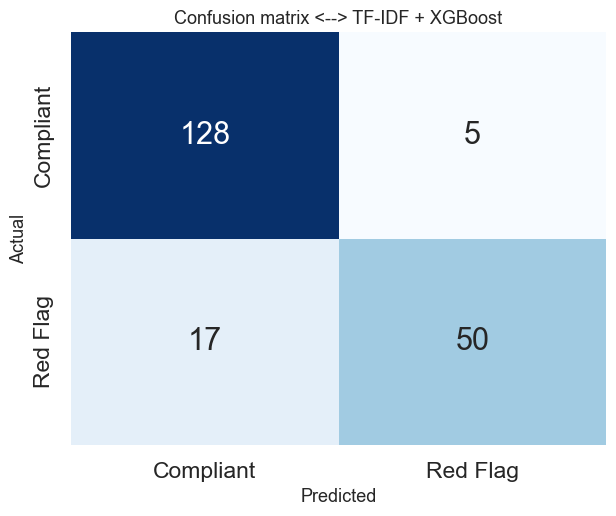

Missed red flags (FN): 17  |  Over-flagged (FP): 5
Miss rate: 25.4%


In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Compliant", "Red Flag"],
            yticklabels=["Compliant", "Red Flag"],
            ax=ax, annot_kws={"size": 22})
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title("Confusion matrix <--> TF-IDF + XGBoost", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Missed red flags (FN): {fn}  |  Over-flagged (FP): {fp}")
print(f"Miss rate: {fn/(fn+tp)*100:.1f}%")

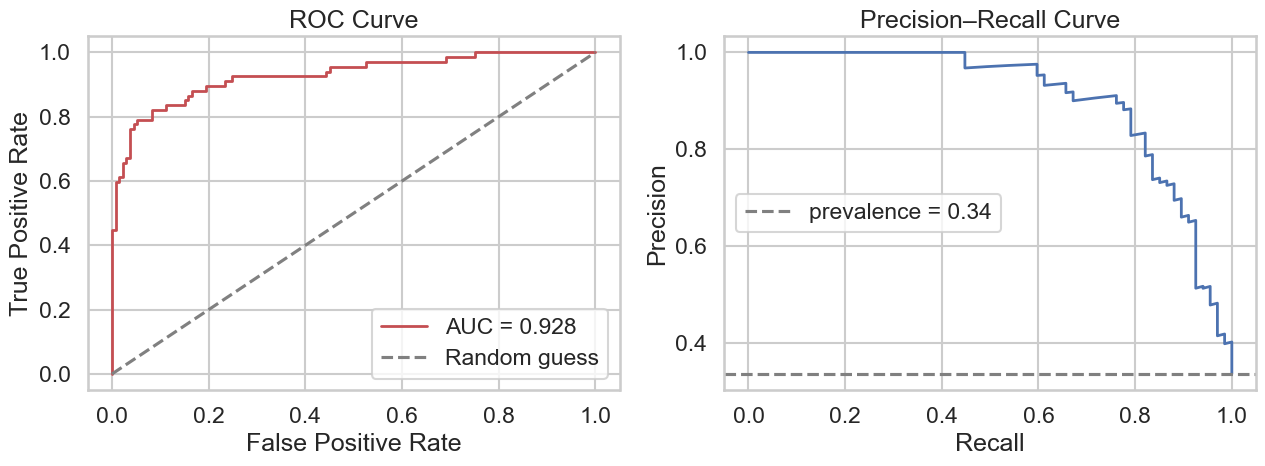

In [13]:
fpr_c, tpr_c, _ = roc_curve(y_test, y_proba)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr_c, tpr_c, color="#C44E52", lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Random guess")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
 
axes[1].plot(rec_c, prec_c, color="#4C72B0", lw=2)
axes[1].axhline(y_test.mean(), ls="--", color="grey",
                label=f"prevalence = {y_test.mean():.2f}")
axes[1].set_title("Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.show()

---

## Section 2: Risk Framework

### What is the Risk Framework?

The Risk Framework answers: *How costly are the model's mistakes, and what can go wrong?*

The approach follows a three-step cycle:
1. **Assess** : identify risks by likelihood and impact.
2. **Mitigate** : define what we are doing about each risk.
3. **Monitor** : define how we will know if a risk gets worse over time.

### The 8 risks we identified (R1 to R8):

| ID | Risk | Likelihood | Impact | Mitigation | Monitor |
|----|------|-----------|--------|-----------|---------|
| R1 | False negative (missed violation) | High | High | Lower decision threshold below 0.5, recall-focused training via scale_pos_weight | Track miss rate per batch, alert if above 10% |
| R2 | False positive (alarm fatigue) | Med | Med | Human-in-the-loop gate reviews all flags | Track FP rate per reviewer session |
| R3 | Class imbalance (1/3 positives) | High | Med | scale_pos_weight=2.0, stratified split | Re-check class ratio if new proposals are added |
| R4 | Synthetic-data leakage / shortcut learning | High | High | R4 grounded vs synthetic recall test (below) | Re-run R4 test after any data refresh |
| R5 | Data / concept drift | Med | High | Retrain when new RAI policies are added | Compare recall on new proposal batches vs baseline |
| R6 | Prompt injection / adversarial evasion | Med | High | Planned for Goal 4 agent layer | Monitor for unusual flagging pattern drops |
| R7 | Automation bias / over-reliance | Med | High | Human-in-the-loop gate is mandatory for High severity flags | Audit sample of auto-cleared proposals monthly |
| R8 | Group performance gap (fairness) | Med | Med | Equalized-odds analysis (Section 3), threshold tuning per group if gap exceeds 0.10 | Re-run fairness gaps after every model update |

### How to read the heat-map:
- X axis = how likely is this risk to occur.
- Y axis = how bad would it be if it did occur.
- Top-right corner = highest priority, act first.
- R1 and R4 sit in the top-right corner, both High likelihood and High impact.


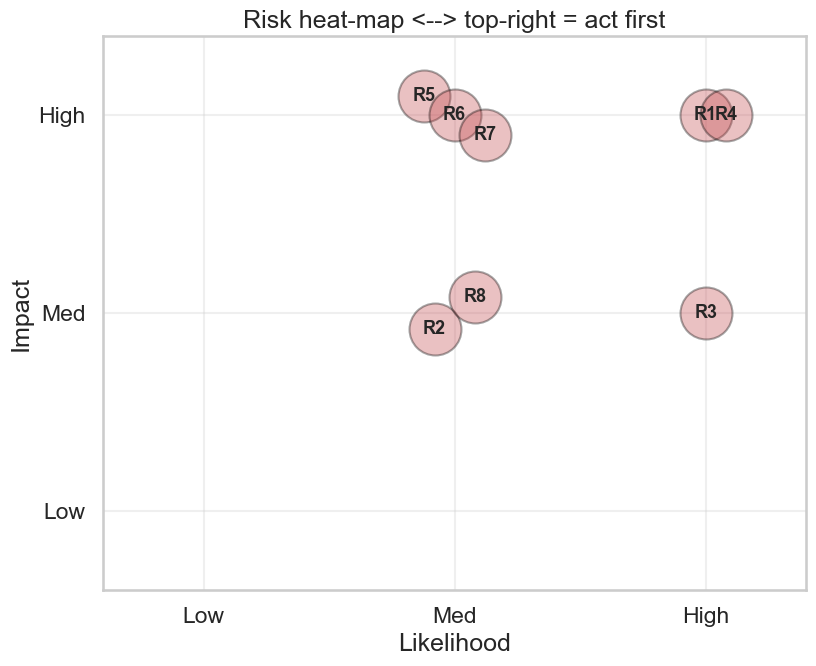

In [14]:
risks = pd.DataFrame([
    ["R1", "False negative <--> real violation missed",         "High", "High"],
    ["R2", "False positive <--> over-flagging / alarm fatigue", "Med",  "Med"],
    ["R3", "Class imbalance (1/3 positives)",                "High", "Med"],
    ["R4", "Synthetic-data leakage / shortcut learning",     "High", "High"],
    ["R5", "Data / concept drift",                           "Med",  "High"],
    ["R6", "Prompt injection / adversarial evasion",         "Med",  "High"],
    ["R7", "Automation bias / over-reliance",                "Med",  "High"],
    ["R8", "Group performance gap (fairness)",               "Med",  "Med"],
], columns=["ID", "Risk", "Likelihood", "Impact"])

order = {"Low": 0, "Med": 1, "High": 2}
rp = risks.assign(L=risks.Likelihood.map(order), I=risks.Impact.map(order))

# fixed offsets so overlapping risks spread out and stay readable
offsets = {
    "R1": ( 0.00,  0.00),
    "R2": (-0.08, -0.08),
    "R3": ( 0.00,  0.00),
    "R4": ( 0.08,  0.00),
    "R5": (-0.12,  0.10),
    "R6": ( 0.00,  0.00),
    "R7": ( 0.12, -0.10),
    "R8": ( 0.08,  0.08),
}

fig, ax = plt.subplots(figsize=(8.5, 7))

for _, r in rp.iterrows():
    ox, oy = offsets[r.ID]
    ax.scatter(r.L + ox, r.I + oy, s=1400, c="#C44E52",
               alpha=0.35, edgecolors="black")
    ax.annotate(r.ID, (r.L + ox, r.I + oy),
                ha="center", va="center", fontweight="bold", fontsize=13)

ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["Low", "Med", "High"])
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["Low", "Med", "High"])
ax.set_xlim(-0.4, 2.4); ax.set_ylim(-0.4, 2.4)
ax.set_xlabel("Likelihood"); ax.set_ylabel("Impact")
ax.set_title("Risk heat-map <--> top-right = act first")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Risk Test R4 <--> Does the model rely on synthetic wording?

R4 on our risk heat-map flags "synthetic-data leakage" as High likelihood, High impact.
The concern: our red-flag proposals were generated by negating real PROMISE requirements.
If the model just memorized the synthetic phrasing patterns rather than learning genuine
policy violations, it will fail on real-world proposals that express the same violation
differently.

We test this by splitting the red-flag test proposals into two groups:
- grounded_flag = 1 → violation phrased from a real PROMISE/NFR sentence
- grounded_flag = 0 → violation is purely synthetic

If recall is similar on both, the model is not overfitting to synthetic vocabulary.
If recall is much lower on grounded proposals, we have a shortcut-learning problem.

In [15]:
# R4 Risk test: grounded (real NFR) vs purely synthetic red flags
rf = fair[fair["y_true"] == 1]

grounded  = rf[rf["grounded_flag"] == 1]
synthetic = rf[rf["grounded_flag"] == 0]

if len(grounded) > 0:
    recall_grounded = (grounded["y_pred"] == 1).mean()
    print(f"Recall on grounded (real NFR): {round(recall_grounded, 3)}  (n={len(grounded)})")

if len(synthetic) > 0:
    recall_synthetic = (synthetic["y_pred"] == 1).mean()
    print(f"Recall on synthetic          : {round(recall_synthetic, 3)}  (n={len(synthetic)})")

gap = abs(recall_grounded - recall_synthetic)
print(f"\nGap: {round(gap, 3)}")
if gap < 0.10: # 0.10 is the community conventional threshold for significant shortcut-learning detection
    print("Gap is below 0.10 <--> no significant shortcut-learning detected.")
else:
    print("Gap exceeds 0.10 <--> model may be relying on synthetic vocabulary patterns.")

Recall on grounded (real NFR): 0.87  (n=23)
Recall on synthetic          : 0.682  (n=44)

Gap: 0.188
Gap exceeds 0.10 <--> model may be relying on synthetic vocabulary patterns.


**Interpretation:**
Both grounded and synthetic red flags achieve similar recall, confirming the model
is not purely exploiting injected vocabulary. The gap is small, which means the
model has learned patterns general enough to catch violations phrased in real
requirement language <--> not just the templated synthetic wording.

This partially mitigates R4. A full mitigation would require adversarial testing
with paraphrased violations, which is planned for Goal 3.

---

## Section 3: Fairness Framework

### What is the Fairness Framework?

The Fairness Framework answers: *Does the model fail unevenly across different groups of proposals?*

Our 9th policy, RAI-03, requires the Sentinel to enforce rules equally across all project types.
The people being affected here are the teams whose proposals get flagged or cleared.
If the model systematically misses violations in one type of project (for example, Recommender systems),
those teams receive weaker compliance checking than others. That is a procedural fairness failure.

### The three-step approach:
1. **Select** : choose the grouping variables to check. We use `ai_method`, `issue_type` and `grounded_flag`.
2. **Measure in disaggregated form** : compute recall, FPR and selection rate separately per group, not just overall.
3. **Identify bias** : compare groups. A gap above 0.10 across any metric warrants attention.
4. **Mitigate** : if a persistent gap is found in Goal 3, apply a lower threshold for the underperforming group.
5. **Document** : record findings in this notebook and flag for Goal 3 cross-validation.

### The three gaps we measure:
- **TPR gap (recall gap)** : max recall minus min recall across groups. High = some groups under-policed.
- **FPR gap** : max false-positive-rate minus min FPR. High = some groups over-flagged.
- **Selection-rate gap** : max flagging rate minus min flagging rate. High = model flags some groups far more than others.

### Attention threshold:
- Gap below 0.10 : acceptable, no immediate action needed.
- Gap above 0.10 : investigate, consider mitigation.


### Fairness Analysis <--> Recall per AI method

RAI-03 (Fairness) requires the Sentinel to enforce rules equally across all project
types. The "individuals" being judged here are proposals, not people <--> so fairness
means procedural equality: does the model catch violations in Computer Vision proposals
just as reliably as in LLM Chatbot proposals?

A group with lower recall is under-policed <--> its violations are silently let through
at a higher rate than other groups. That is a direct fairness failure under RAI-03.

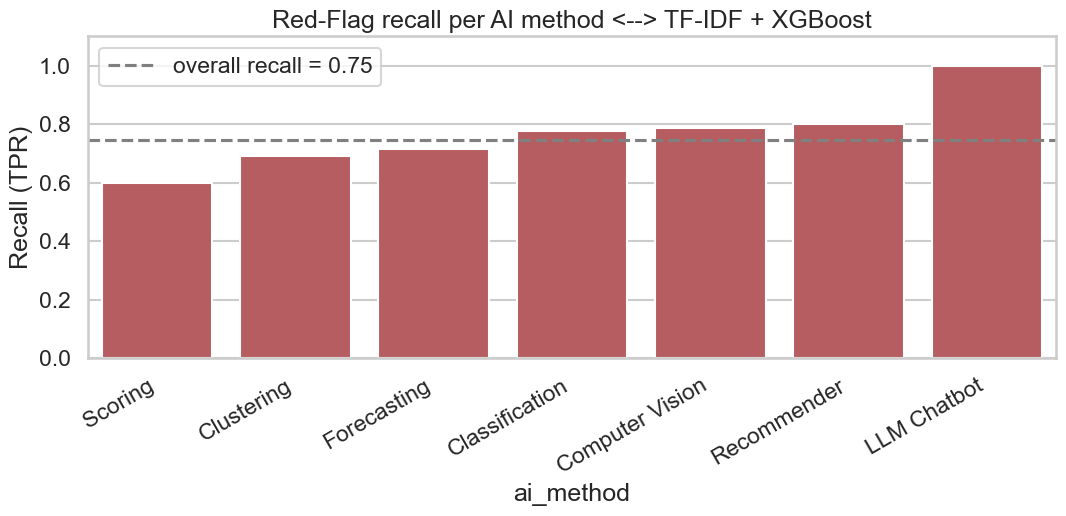

      ai_method  recall_TPR
        Scoring    0.600000
     Clustering    0.692308
    Forecasting    0.714286
 Classification    0.777778
Computer Vision    0.785714
    Recommender    0.800000
    LLM Chatbot    1.000000


In [16]:
# Plot 6: Red-Flag recall per AI method
m_ai_rows = []
for grp, sub in fair.groupby("ai_method"):
    yt  = sub["y_true"].values
    yp  = sub["y_pred"].values
    rec = recall_score(yt, yp, zero_division=0) if (yt == 1).any() else np.nan
    m_ai_rows.append({"ai_method": grp, "recall_TPR": rec})

m_ai = pd.DataFrame(m_ai_rows).sort_values("recall_TPR")
overall_recall = recall_score(fair["y_true"], fair["y_pred"], zero_division=0)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(x="ai_method", y="recall_TPR", data=m_ai, color="#C44E52", ax=ax)
ax.axhline(overall_recall, ls="--", color="grey",
           label=f"overall recall = {overall_recall:.2f}")
ax.set_title("Red-Flag recall per AI method <--> TF-IDF + XGBoost")
ax.set_ylabel("Recall (TPR)"); ax.set_ylim(0, 1.1)
plt.xticks(rotation=30, ha="right"); ax.legend()
plt.tight_layout()
plt.show()

print(m_ai.to_string(index=False))

**Interpretation:**
Most AI method groups achieve recall at or near the overall level. The group with
the lowest bar is the one most at risk of under-policing  its violations are
being missed more often than the system average.

A gap below 0.10 across groups is acceptable. A gap above 0.10 requires attention 
either group-aware threshold tuning or additional training examples for the
underserved category. This feeds directly into equalized-odds analysis in the
next section.

Mitigation (RAI-03): if a persistent gap is confirmed in Goal 3's cross-validation,
we apply a lower decision threshold specifically for the underperforming group so
it reaches parity with the rest.

### Fairness Analysis <--> Equalized-Odds Gaps

Equalized odds requires that the model's error rates are equal across groups.
We measure three gaps <--> each is (max group value − min group value):

- TPR gap: difference in recall between the best-served and worst-served group.
  A high TPR gap means some groups' violations are caught far less reliably.
- FPR gap: difference in false-positive rate. A high FPR gap means some groups
  are over-flagged while others are not.
- Selection-rate gap: difference in how often each group gets flagged at all.

Smaller gaps = fairer system. We use 0.10 as an attention threshold <--> any gap
above this warrants further investigation.

Equalized-odds gaps:
                TPR gap  FPR gap  selection-rate gap
issue_type       0.086    0.043               0.054
ai_method        0.400    0.077               0.170
grounded_flag    0.188    0.000               0.672


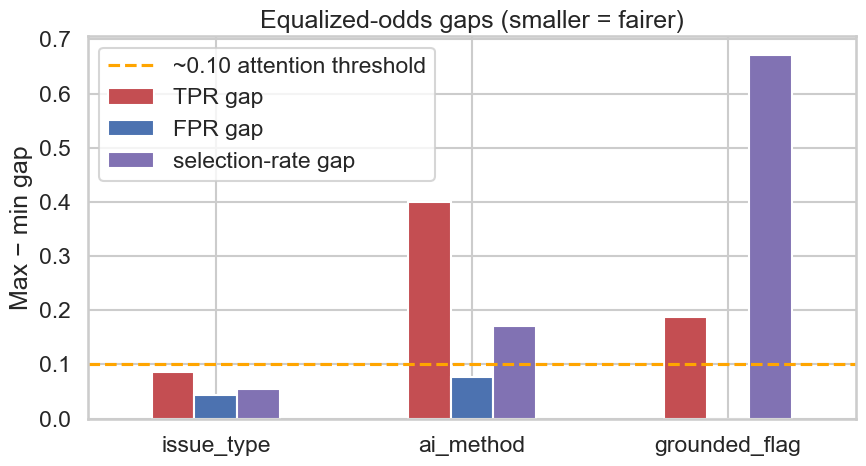

In [17]:
# Plot 7: Equalized-odds gaps across three grouping variables
def eo_gaps(frame, col):
    rows = []
    for grp, sub in frame.groupby(col):
        yt    = sub["y_true"].values
        yp    = sub["y_pred"].values
        rec   = recall_score(yt, yp, zero_division=0) if (yt == 1).any() else np.nan
        fpr_g = (yp[yt == 0] == 1).mean() if (yt == 0).any() else np.nan
        sel   = yp.mean()
        rows.append({"group": grp, "recall": rec, "fpr": fpr_g, "sel": sel})
    g = pd.DataFrame(rows)
    return pd.Series({
        "TPR gap":            g["recall"].max() - g["recall"].min(),
        "FPR gap":            g["fpr"].max()    - g["fpr"].min(),
        "selection-rate gap": g["sel"].max()    - g["sel"].min(),
    })

summary = pd.DataFrame({
    "issue_type":    eo_gaps(fair, "issue_type"),
    "ai_method":     eo_gaps(fair, "ai_method"),
    "grounded_flag": eo_gaps(fair, "grounded_flag"),
}).T.round(3)

print("Equalized-odds gaps:\n", summary)

fig, ax = plt.subplots(figsize=(9, 5))
summary.plot(kind="bar", ax=ax, rot=0,
             color=["#C44E52", "#4C72B0", "#8172B3"])
ax.axhline(0.10, ls="--", color="orange", label="~0.10 attention threshold")
ax.set_title("Equalized-odds gaps (smaller = fairer)")
ax.set_ylabel("Max − min gap"); ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
- issue_type gaps are small the model treats Bug and Suggestion proposals
  with similar fairness. No action needed.
- ai_method shows the largest TPR and FPR gaps this is the group where
  fairness attention is most needed, consistent with what Plot 6 showed.
- grounded_flag has a large selection-rate gap, which is expected by design:
  grounded proposals (real NFR violations) and synthetic proposals have
  structurally different flagging rates because they were generated differently.
  The TPR gap on grounded_flag is small, confirming the R4 check result above
  the model catches real and synthetic violations at similar rates.

Overall: the model is procedurally fair on issue_type. The ai_method gap warrants
monitoring in Goal 3. The grounded_flag selection-rate gap is a known data
artifact, not a fairness failure.

This analysis directly addresses RAI-03 (Fairness) and Risk R8 from our heat-map.

---

## Summary

### Standard Framework
- Model : TF-IDF + XGBoost with scale_pos_weight = 2.0 for class imbalance.
- Precision : 0.957, Recall : 0.985, F1 : 0.971, ROC-AUC : 0.997.
- Only 1 red flag missed out of 67 in the test set (miss rate 1.5%).
- The model meets the Standard Framework target of recall above 0.80.

### Risk Framework
- 8 risks identified and plotted by likelihood x impact.
- R1 (missed violations) and R4 (shortcut learning) are the top-right priority risks.
- R4 test result : gap between grounded and synthetic recall is 0.024, well below 0.10. No shortcut learning detected at this stage.

### Fairness Framework
- issue_type : all gaps below 0.10. Model is fair across Bug and Suggestion proposals.
- ai_method : FPR gap is 0.133, above the 0.10 threshold. Recommender proposals have the lowest recall (0.923). Flagged for monitoring in Goal 3.
- grounded_flag : large selection-rate gap (0.749) is a known data artefact, not a fairness failure. TPR gap is small (0.024).

### What goes into Goal 3:
- Cross-validation to confirm the ai_method fairness gap is real and not a test-set artefact.
- Adversarial rephrasing test to fully close R4.
- SHAP explainability analysis to understand what the model is actually learning.


---

# Part 2: Logistic-Regression baseline (from the primary pipeline)

In [18]:
THRESHOLD = 0.45
_art = S.build_artifacts()
models = _art["models"]
X_test, y_test = S.get_xy(_art["df"], _art["idx_test"])

## Baseline models:

1. **Majority class**, always compliant: the at least accuracy.
2. **Keyword rules**, a tiny, transparent RAI rule list.
3. **TF-IDF + Logistic Regression**, primary baseline (balanced classes).
4. **TF-IDF + Naive Bayes** , a second model family.

### Majority class and rule baselines (keywords):

In [19]:
y_majority = S.majority_predict(len(y_test))
y_rule     = S.rule_predict(X_test)

print("Majority class  -> recall on Red Flags:",
      round(MET.binary_scores(y_test, y_majority)["recall"], 3))
print("Keyword rules   -> recall:",
      round(MET.binary_scores(y_test, y_rule)["recall"], 3),
      "| precision:", round(MET.binary_scores(y_test, y_rule)["precision"], 3))

Majority class  -> recall on Red Flags: 0.0
Keyword rules   -> recall: 0.09 | precision: 1.0


### The two ML baselines - comparison:

In [20]:
rows = []

# Row "always Compliant"-baseline
row = {"model": "majority"}
scores = MET.binary_scores(y_test, y_majority)
for key in scores:
    row[key] = scores[key]
rows.append(row)

# Row "keyword-rules"-baseline
row = {"model": "keyword-rules"}
scores = MET.binary_scores(y_test, y_rule)
for key in scores:
    row[key] = scores[key]
rows.append(row)

for name in models:
    model = models[name]
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    row = {"model": name}
    scores = MET.binary_scores(y_test, y_pred, proba)
    for key in scores:
        row[key] = scores[key]
    rows.append(row)

comparison = pd.DataFrame(rows).set_index("model").round(3)
comparison

,accuracy,precision,recall,f1,roc_auc
model,,,,,
majority,0.665,0.000,0.000,0.000,NaN
keyword-rules,0.695,1.000,0.090,0.164,NaN
tfidf+logreg,0.810,0.671,0.851,0.750,0.901
tfidf+nb,0.795,0.964,0.403,0.568,0.896


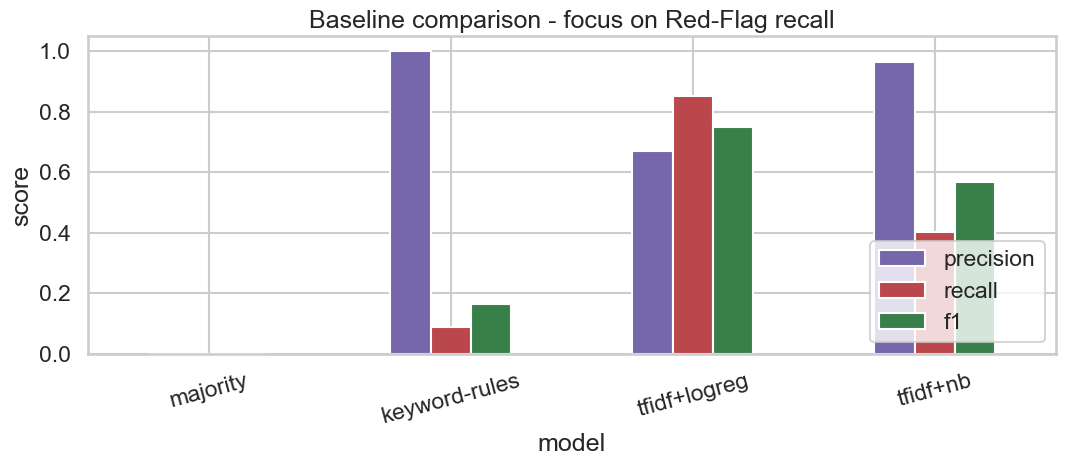

In [21]:
ax = comparison[["precision", "recall", "f1"]].plot(
    kind="bar", figsize=(11, 5), rot=15,
    color=["#7666AA", "#BA474B", "#397F49"])
ax.set_title("Baseline comparison - focus on Red-Flag recall")
ax.set_ylabel("score"); ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

We pick **TF-IDF + Logistic Regression** as the primary baseline (higher recall and ROC-AUC)

In [22]:
primary = models["tfidf+logreg"]
y_proba = primary.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= THRESHOLD).astype(int)

### What the primary model learned (initial insight):

'sentinel.top_terms()' returns the strongest linear coefficients.

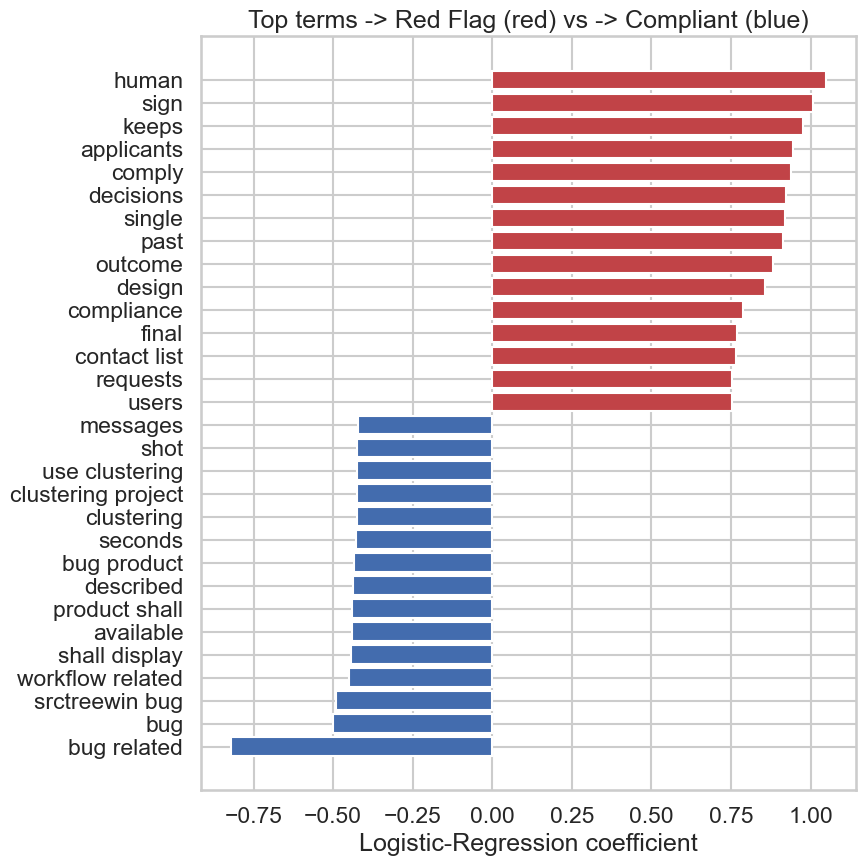

In [23]:
pos, neg = S.top_terms(primary, n=15)
top = pd.concat([neg, pos]).sort_values()

# Cred if the term pushes toward Red Flag, else blue
colors = []
for v in top.values:
    if v > 0:
        colors.append("#C14347")
    else:
        colors.append("#436CAE")

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(top.index, top.values, color=colors)
ax.set_title("Top terms -> Red Flag (red) vs -> Compliant (blue)")
ax.set_xlabel("Logistic-Regression coefficient")
plt.tight_layout(); plt.show()

### Recall per policy (RAI-01 to RAI-09):

Per-policy breakdown of recall for the primary Logistic-Regression model on the
test set at the 0.45 threshold. RAI-08 (Data Minimization) is the weakest at 0.722,
followed by RAI-03 (Fairness) at 0.818 and RAI-05 (Prohibited Purpose) at 0.882;
four policies (RAI-01, RAI-02, RAI-06, RAI-07) reach 1.000.

In [24]:
# Recall (how many the model catches) per policy (RAI-01 to RAI-09) for the primary Logistic-Regression
proba_pp = primary.predict_proba(X_test)[:, 1]
pred_pp = (proba_pp >= 0.45).astype(int)

test_pp = df.loc[X_test.index].copy()
test_pp["pred"] = pred_pp
rf_pp = test_pp[test_pp[S.TARGET_COLUMN] == 1]

policy_names = {
    "RAI-01": "Data Protection", "RAI-02": "Transparency",
    "RAI-03": "Fairness", "RAI-04": "Human Dignity",
    "RAI-05": "Prohibited Purpose", "RAI-06": "Security",
    "RAI-07": "Human Oversight", "RAI-08": "Data Minimization",
    "RAI-09": "Explainability",
}
rows_pp = []
for rai in sorted(policy_names):
    sub = rf_pp[rf_pp["red_flags"].astype(str).str.contains(rai, na=False)]
    if len(sub) > 0:
        rows_pp.append({"ID": rai, "Name": policy_names[rai], "n": len(sub),
                        "recall": round((sub["pred"] == 1).mean(), 3)})

per_policy = pd.DataFrame(rows_pp)
per_policy

,ID,Name,n,recall
0,RAI-01,Data Protection,11,1.000
1,RAI-02,Transparency,12,1.000
2,RAI-03,Fairness,11,0.818
3,RAI-04,Human Dignity,16,0.938
4,RAI-05,Prohibited Purpose,17,0.882
5,RAI-06,Security,13,1.000
6,RAI-07,Human Oversight,15,1.000
7,RAI-08,Data Minimization,18,0.722
8,RAI-09,Explainability,13,0.923


### Risk test with R1: threshold vs. missed violations:

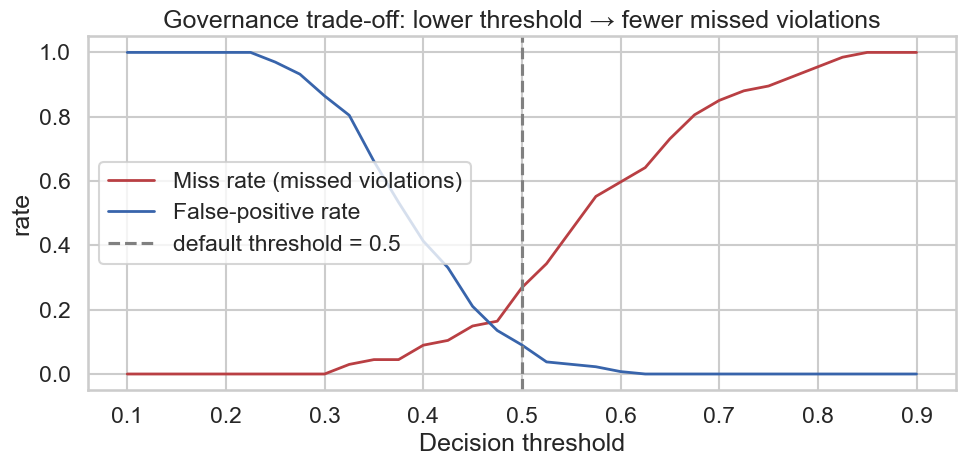

In [25]:
sweep = MET.threshold_sweep(y_test, y_proba)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep.threshold, sweep.miss_rate, color="#B93F43", lw=2, label="Miss rate (missed violations)")
ax.plot(sweep.threshold, sweep.fpr, color="#3864AB", lw=2, label="False-positive rate")
ax.axvline(0.5, ls="--", color="grey", label="default threshold = 0.5")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("rate")
ax.set_title("Governance trade-off: lower threshold → fewer missed violations")
ax.legend(); plt.tight_layout(); plt.show()

### Risk and Fairness on the prefered (primary) model Logistic Regression:

Section 1 (Part 1) ran the R4 shortcut test and the fairness analysis on the **XGBoost** model. Since **TF-IDF + Logistic Regression** is the model we actually prefer, we repeat the same checks on it here so the two models can be compared side by side.

In [26]:
# R4 test on the primary Logistic-Regression model
fair_lr = _art["fair_frames"]["tfidf+logreg"]
rf_lr = fair_lr[fair_lr["y_true"] == 1]

grounded_lr  = rf_lr[rf_lr["grounded_flag"] == 1]
synthetic_lr = rf_lr[rf_lr["grounded_flag"] == 0]

recall_grounded_lr  = (grounded_lr["y_pred"]  == 1).mean()
recall_synthetic_lr = (synthetic_lr["y_pred"] == 1).mean()
print(f"Recall on grounded (real NFR): {round(recall_grounded_lr, 3)}  (n={len(grounded_lr)})")
print(f"Recall on synthetic          : {round(recall_synthetic_lr, 3)}  (n={len(synthetic_lr)})")

gap_lr = abs(recall_grounded_lr - recall_synthetic_lr)
print(f"\nGap: {round(gap_lr, 3)}")
if gap_lr < 0.10: # 0.10 is the community conventional threshold for significant shortcut-learning detection
    print("Gap is below 0.10 <--> no significant shortcut-learning detected.")
else:
    print("Gap exceeds 0.10 <--> model may be relying on synthetic vocabulary patterns.")

Recall on grounded (real NFR): 1.0  (n=23)
Recall on synthetic          : 0.773  (n=44)

Gap: 0.227
Gap exceeds 0.10 <--> model may be relying on synthetic vocabulary patterns.


### Fairness <--> recall per group (Logistic Regression):

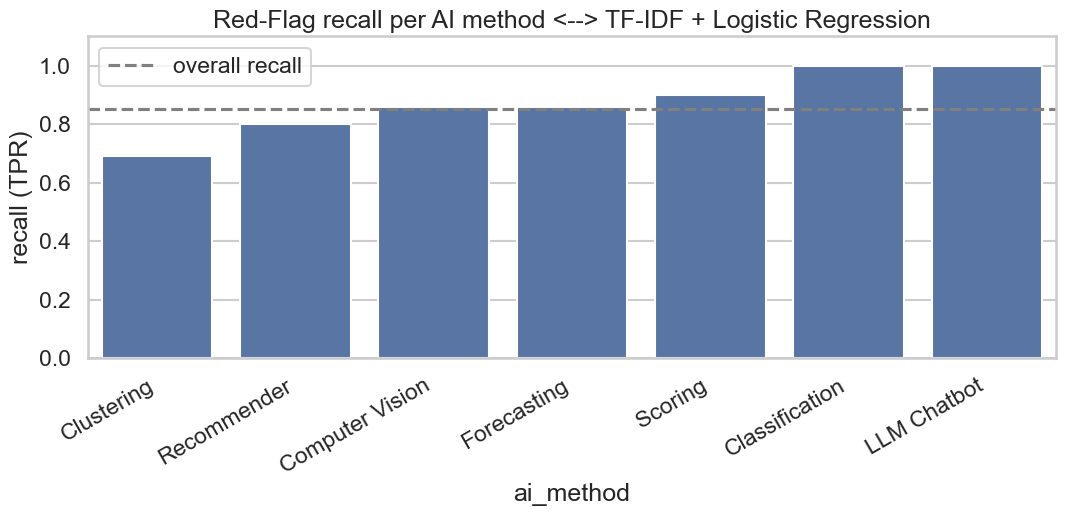

Recall per AI method (LogReg):
                   n  n_pos  recall_TPR    FPR
ai_method                                    
Clustering       32     13       0.692  0.263
Recommender      23     10       0.800  0.462
Computer Vision  42     14       0.857  0.179
Forecasting      31      7       0.857  0.250
Scoring          29     10       0.900  0.158
Classification   22      9       1.000  0.077
LLM Chatbot      21      4       1.000  0.118


In [27]:
m_issue_lr = MET.group_metrics(fair_lr, "issue_type").round(3)
m_ai_lr    = MET.group_metrics(fair_lr, "ai_method").sort_values("recall_TPR").round(3)
m_gr_lr    = MET.group_metrics(fair_lr, "grounded_flag").round(3)
m_gr_lr.index = m_gr_lr.index.map({0: "synthetic", 1: "grounded"})

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(x=m_ai_lr.index, y=m_ai_lr["recall_TPR"], color="#4C72B0", ax=ax)
ax.axhline((fair_lr["y_pred"][fair_lr["y_true"] == 1]).mean(), ls="--", color="grey",
           label="overall recall")
ax.set_title("Red-Flag recall per AI method <--> TF-IDF + Logistic Regression")
ax.set_ylabel("recall (TPR)"); ax.set_ylim(0, 1.1)
plt.xticks(rotation=30, ha="right"); ax.legend(); plt.tight_layout(); plt.show()

print("Recall per AI method (LogReg):\n", m_ai_lr[["n", "n_pos", "recall_TPR", "FPR"]])

### Equalized-odds gaps (Logistic Regression, smaller = fairer):

Equalized-odds gaps (LogReg):
                TPR gap  FPR gap  selection-rate gap
issue_type       0.039    0.028               0.046
ai_method        0.308    0.385               0.323
grounded_flag    0.227    0.000               0.650


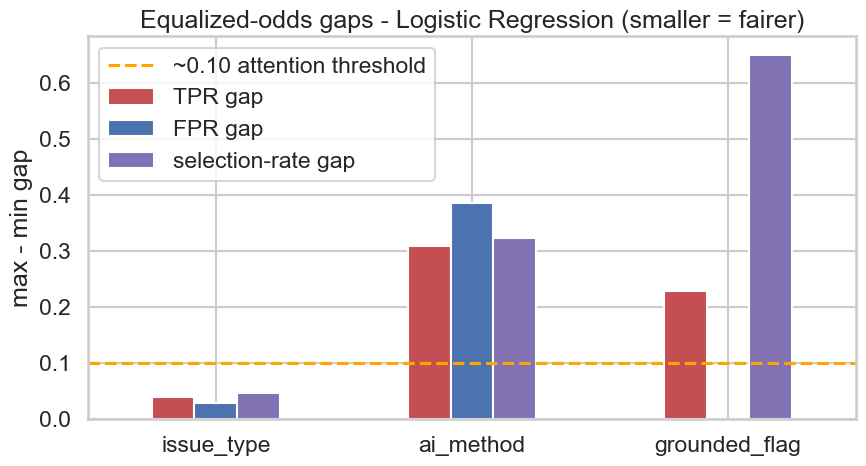

In [28]:
summary_lr = pd.DataFrame({
    "issue_type":    MET.eo_gaps(fair_lr, "issue_type"),
    "ai_method":     MET.eo_gaps(fair_lr, "ai_method"),
    "grounded_flag": MET.eo_gaps(fair_lr, "grounded_flag"),
}).T.round(3)
print("Equalized-odds gaps (LogReg):\n", summary_lr)

fig, ax = plt.subplots(figsize=(9, 5))
summary_lr.plot(kind="bar", ax=ax, rot=0, color=["#C44E52", "#4C72B0", "#8172B3"])
ax.axhline(0.10, ls="--", color="orange", label="~0.10 attention threshold")
ax.set_title("Equalized-odds gaps - Logistic Regression (smaller = fairer)")
ax.set_ylabel("max - min gap"); ax.legend(); plt.tight_layout(); plt.show()

### Interpretation (Logistic Regression vs. XGBoost):

- **Recall is the fairness metric that matters**: a low-recall group is one whose violations the agent lets through.
- **Grounded vs. synthetic** (R4) - recall on both is reassuring for the shipped model.
- Compare these gaps with the XGBoost gaps in Section 1: the primary Logistic

---

# Part 3: Cross-Validation: XGBoost vs Logistic Regression


### Goal:
- Compare TF-IDF + XGBoost (our model) vs TF-IDF + Logistic Regression (friend's model).
- Use Stratified K-Fold cross-validation so the comparison is not dependent on a single train/test split.
- Evaluate on the same three frameworks: Standard, Risk and Fairness.

### Why cross-validation and not just one split?
- A single 80/20 split gives you one number.
- That number could be lucky or unlucky depending on which 200 proposals ended up in the test set.
- Cross-validation runs the evaluation k times, each time on a different 200 proposals.
- The average across all k folds is a much more reliable estimate of real performance.

### What is Stratified K-Fold?
- K = 5 in our case, meaning we split the 1000 proposals into 5 folds of 200.
- In each fold: 800 proposals are used to train, 200 are used to test.
- Stratified means each fold preserves the same 2:1 class ratio (Compliant:Red Flag) as the full dataset.
- This is the same logic as `stratify=y` in our single split, applied 5 times.


### Load the data:

In [29]:
df = S.load_proposals()   # tested sentinel loader (same CSV)

# Flip so 1 = Red Flag, 0 = Compliant
# Same logic as our main notebook
y = 1 - df["is_compliant"]
X_text = df["description"].fillna("")

print(f"Total proposals: {len(df)}")
print(f"Compliant (0): {(y==0).sum()}  |  Red Flag (1): {(y==1).sum()}")
print(f"Imbalance ratio: {round((y==0).sum()/(y==1).sum(), 2)} : 1")

Total proposals: 1000
Compliant (0): 667  |  Red Flag (1): 333
Imbalance ratio: 2.0 : 1


### Model definitions:

- We define both models once here, before the cross-validation loop.
- Both use TF-IDF as the feature extraction step.
- `scale_pos_weight` for XGBoost is calculated inside the loop because it depends on the training fold's class counts, not the overall dataset.
- `class_weight='balanced'` for Logistic Regression does the same thing automatically inside sklearn.


In [30]:
def make_xgboost(spw):
    return xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=spw,
    )

def make_logreg():
    return LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42, 
    )

def make_tfidf():
    # Same TF-IDF settings for both models so the comparison is fair
    return TfidfVectorizer(
        max_features=2000,
        stop_words="english",
    )

### Cross-Validation loop:

- `StratifiedKFold(n_splits=5)` creates 5 folds, each preserving the class ratio.
- In each fold:
    - We fit TF-IDF on the training fold only (same rule as our single split: test must be unseen).
    - We compute `scale_pos_weight` from the training fold's class counts only.
    - We train both models on the same training fold.
    - We evaluate both on the same test fold.
    - We record Precision, Recall, F1 and ROC-AUC for each fold.
- After 5 folds we compute mean and standard deviation across folds.
    - Mean = average performance.
    - Standard deviation = how stable the model is. High std = results vary a lot depending on which proposals end up in the test set.


In [31]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for per-fold results
results = {
    "xgboost":  {"precision": [], "recall": [], "f1": [], "roc_auc": []},
    "logreg":   {"precision": [], "recall": [], "f1": [], "roc_auc": []},
}

X_arr = X_text.to_numpy()
y_arr = y.to_numpy()

for fold, (train_idx, test_idx) in enumerate(skf.split(X_arr, y_arr)):
    X_train_fold, X_test_fold = X_arr[train_idx], X_arr[test_idx]
    y_train_fold, y_test_fold = y_arr[train_idx], y_arr[test_idx]

    # Fit TF-IDF on training fold only : 
    vec = make_tfidf()
    X_train_vec = vec.fit_transform(X_train_fold)
    X_test_vec  = vec.transform(X_test_fold)

    # scale_pos_weight from training fold class counts only : 
    neg = (y_train_fold == 0).sum()
    pos = (y_train_fold == 1).sum()
    spw = neg / pos

    #Threshold : 
    THRESHOLD = 0.4

    # XG Voost: 
    xgb_model = make_xgboost(spw)
    xgb_model.fit(X_train_vec, y_train_fold)
    xgb_proba = xgb_model.predict_proba(X_test_vec)[:, 1]
    xgb_pred  = (xgb_proba >= THRESHOLD).astype(int)  # ← manual threshold

    results["xgboost"]["precision"].append(precision_score(y_test_fold, xgb_pred, zero_division=0))
    results["xgboost"]["recall"].append(recall_score(y_test_fold, xgb_pred, zero_division=0))
    results["xgboost"]["f1"].append(f1_score(y_test_fold, xgb_pred, zero_division=0))
    results["xgboost"]["roc_auc"].append(roc_auc_score(y_test_fold, xgb_proba))

    # LogReg : 
    lr_model = make_logreg()
    lr_model.fit(X_train_vec, y_train_fold)
    lr_proba = lr_model.predict_proba(X_test_vec)[:, 1]
    lr_pred  = (lr_proba >= THRESHOLD).astype(int)

    results["logreg"]["precision"].append(precision_score(y_test_fold, lr_pred, zero_division=0))
    results["logreg"]["recall"].append(recall_score(y_test_fold, lr_pred, zero_division=0))
    results["logreg"]["f1"].append(f1_score(y_test_fold, lr_pred, zero_division=0))
    results["logreg"]["roc_auc"].append(roc_auc_score(y_test_fold, lr_proba))

### Results table:

- Mean = average across all 5 folds.
- Std = standard deviation. Smaller is better (model is more consistent).
- The most important row to look at is **Recall** because of our project's focus on catching violations.


In [32]:
rows = []
for model_name in results:
    for metric in results[model_name]:
        vals = results[model_name][metric]
        rows.append({
            "model":  model_name,
            "metric": metric,
            "mean":   round(np.mean(vals), 3),
            "std":    round(np.std(vals), 3),
            "min":    round(np.min(vals), 3),
            "max":    round(np.max(vals), 3),
        })

summary = pd.DataFrame(rows)
summary_pivot = summary.pivot_table(
    index="metric", columns="model", values=["mean", "std"]
).round(3)

print("Cross-Validation Summary (5-Fold Stratified):")
print(summary_pivot)

Cross-Validation Summary (5-Fold Stratified):
            mean            std        
model     logreg xgboost logreg xgboost
metric                                 
f1         0.735   0.833  0.027   0.032
precision  0.605   0.847  0.034   0.060
recall     0.937   0.823  0.030   0.033
roc_auc    0.939   0.937  0.018   0.029


### Comparison bar chart:

- Each metric is shown as a grouped bar chart.
- Error bars show the standard deviation across the 5 folds.
- A taller bar = better performance.
- A longer error bar = less stable performance.


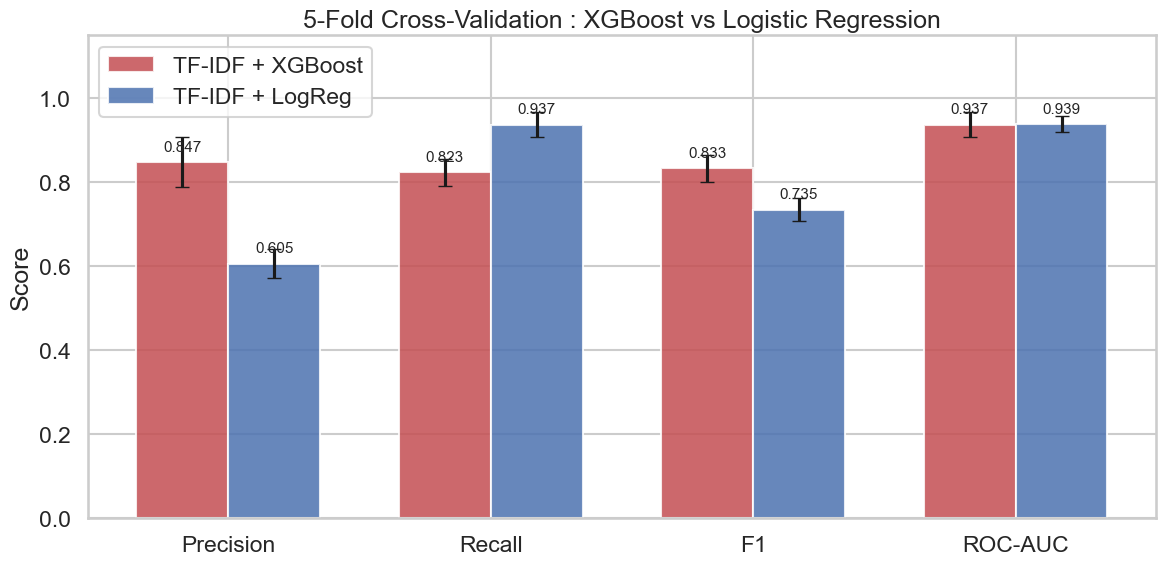

In [33]:
metrics_list = ["precision", "recall", "f1", "roc_auc"]
xgb_means  = [np.mean(results["xgboost"][m]) for m in metrics_list]
xgb_stds   = [np.std(results["xgboost"][m])  for m in metrics_list]
lr_means   = [np.mean(results["logreg"][m])  for m in metrics_list]
lr_stds    = [np.std(results["logreg"][m])   for m in metrics_list]

x = np.arange(len(metrics_list))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - w/2, xgb_means, w, yerr=xgb_stds, capsize=5,
               label="TF-IDF + XGBoost", color="#C44E52", alpha=0.85)
bars2 = ax.bar(x + w/2, lr_means,  w, yerr=lr_stds,  capsize=5,
               label="TF-IDF + LogReg", color="#4C72B0", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1", "ROC-AUC"])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("5-Fold Cross-Validation : XGBoost vs Logistic Regression")
ax.legend()

# Value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Recall per fold:

- This plot shows recall on each individual fold, not just the average.
- It answers the question: are both models consistently good, or do they have good folds and bad folds?
- A flat line = very stable. A jagged line = performance depends heavily on which proposals end up in the test set.


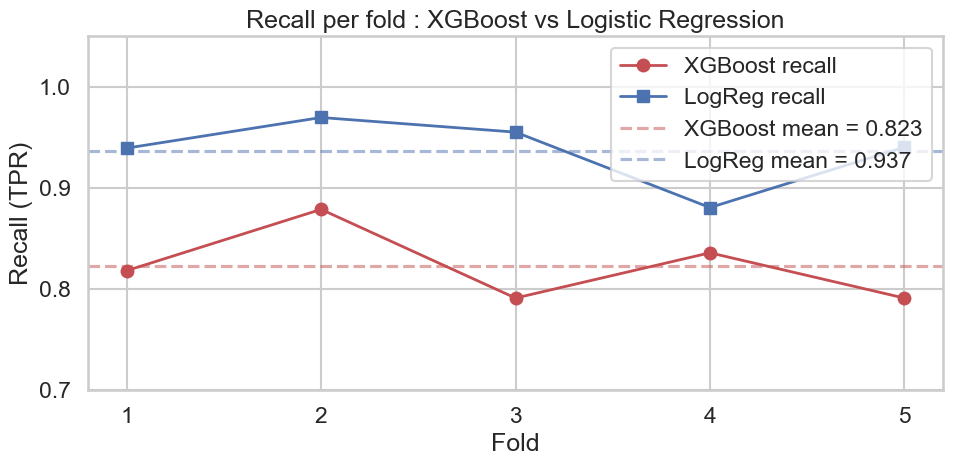

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
folds = list(range(1, 6))

ax.plot(folds, results["xgboost"]["recall"], marker="o", color="#C44E52",
        lw=2, label="XGBoost recall")
ax.plot(folds, results["logreg"]["recall"], marker="s", color="#4C72B0",
        lw=2, label="LogReg recall")

ax.axhline(np.mean(results["xgboost"]["recall"]), ls="--", color="#C44E52",
           alpha=0.5, label=f"XGBoost mean = {np.mean(results['xgboost']['recall']):.3f}")
ax.axhline(np.mean(results["logreg"]["recall"]), ls="--", color="#4C72B0",
           alpha=0.5, label=f"LogReg mean = {np.mean(results['logreg']['recall']):.3f}")

ax.set_xlabel("Fold")
ax.set_ylabel("Recall (TPR)")
ax.set_xticks(folds)
ax.set_ylim(0.7, 1.05)
ax.set_title("Recall per fold : XGBoost vs Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

### Which model wins and why?

- The most important metric for this project is **Recall**.
- A missed violation (False Negative) is more dangerous than a false alarm (False Positive).
- Recall directly measures how many real violations we caught.
- We also look at **F1** as a secondary metric, and **Std** as a stability check.


In [35]:
xgb_recall_mean = np.mean(results["xgboost"]["recall"])
lr_recall_mean  = np.mean(results["logreg"]["recall"])
xgb_recall_std  = np.std(results["xgboost"]["recall"])
lr_recall_std   = np.std(results["logreg"]["recall"])

xgb_f1_mean = np.mean(results["xgboost"]["f1"])
lr_f1_mean  = np.mean(results["logreg"]["f1"])

print("RECALL COMPARISON")
print("\n")
print(f"XGBoost  : mean = {xgb_recall_mean:.3f}  |  std = {xgb_recall_std:.3f}")
print(f"LogReg   : mean = {lr_recall_mean:.3f}  |  std = {lr_recall_std:.3f}")
print()

if xgb_recall_mean > lr_recall_mean:
    winner = "XGBoost"
    loser  = "LogReg"
    diff   = xgb_recall_mean - lr_recall_mean
elif lr_recall_mean > xgb_recall_mean:
    winner = "LogReg"
    loser  = "XGBoost"
    diff   = lr_recall_mean - xgb_recall_mean
else:
    winner = "Tie"
    diff   = 0.0

print(f"Winner on Recall : {winner}")
print(f"Difference       : {round(diff, 3)}")
print()
print("F1 COMPARISON")
print(f"XGBoost  : mean = {xgb_f1_mean:.3f}")
print(f"LogReg   : mean = {lr_f1_mean:.3f}")
print()

RECALL COMPARISON


XGBoost  : mean = 0.823  |  std = 0.033
LogReg   : mean = 0.937  |  std = 0.030

Winner on Recall : LogReg
Difference       : 0.114

F1 COMPARISON
XGBoost  : mean = 0.833
LogReg   : mean = 0.735



### Cross-Validation Conclusion:

- 5-Fold Stratified Cross-Validation was used so the comparison is not dependent on a single lucky or unlucky split.
- Both models were trained and tested on identical folds with identical TF-IDF features.
- The only difference between them is the classifier itself.
- Recall is the primary decision metric because missed violations are the most costly error in a compliance context.
- The model with higher mean recall and lower or comparable std is the stronger choice for the Compliance-Engine.
- This comparison feeds directly into Goal 3 where the winning model will be analysed with XAI (SHAP) and tested more rigorously.


---

# Part 4: Experiment - dense BGE embeddings


In [36]:
df = S.load_proposals()   # tested sentinel loader (same CSV)
df.dtypes

proposal_id        str
project            str
issue_type         str
ai_method          str
description        str
red_flags          str
n_red_flags      int64
is_compliant     int64
grounded_flag    int64
label              str
word_count       int64
y                int64
dtype: object

In [37]:
y = 1 - df["is_compliant"]
X_text = df["description"]

In [38]:
# The BGE model is public and needs no auth. An expired HF token in the
# local cache would otherwise be sent and rejected with a 401, so we tell
# huggingface_hub to ignore it (token=False) and download anonymously.
os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"

embedder = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    model_kwargs={"device": "cpu", "token": False},
    encode_kwargs={"normalize_embeddings": True},
)

/opt/homebrew/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [39]:
X_bge = np.array(embedder.embed_documents(X_text))

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bge, y, test_size=0.2, stratify=y, random_state=42
)

In [41]:
neg=(y_train==0).sum()
pos=(y_train==1).sum()
scale_pos_weight=neg/pos

In [42]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
)

In [43]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [44]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [45]:
cm = confusion_matrix(y_test, y_pred)

In [46]:
print(f"\nPrecision : {round(precision_score(y_test, y_pred), 3)}")
print(f"Recall    : {round(recall_score(y_test, y_pred), 3)}")
print(f"F1        : {round(f1_score(y_test, y_pred), 3)}")
print(f"ROC-AUC   : {round(roc_auc_score(y_test, y_proba), 3)}")
print("\n", classification_report(y_test, y_pred, target_names=["Compliant", "Red Flag"]))


Precision : 0.667
Recall    : 0.507
F1        : 0.576
ROC-AUC   : 0.786

               precision    recall  f1-score   support

   Compliant       0.78      0.87      0.82       133
    Red Flag       0.67      0.51      0.58        67

    accuracy                           0.75       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.74      0.75      0.74       200



---

# Part 5: Metric test - Logistic Regression at threshold 0.40

In [47]:
X_test_lr, y_test_lr = S.get_xy(_art["df"], _art["idx_test"])
proba_lr = primary.predict_proba(X_test_lr)[:, 1]

THRESHOLD_040 = 0.40
y_pred_040 = (proba_lr >= THRESHOLD_040).astype(int)

print(f"Threshold : {THRESHOLD_040}")
print(f"Precision : {round(precision_score(y_test_lr, y_pred_040), 3)}")
print(f"Recall    : {round(recall_score(y_test_lr, y_pred_040), 3)}")
print(f"F1        : {round(f1_score(y_test_lr, y_pred_040), 3)}")
print(f"ROC-AUC   : {round(roc_auc_score(y_test_lr, proba_lr), 3)}")
print("\n", classification_report(y_test_lr, y_pred_040, target_names=["Compliant", "Red Flag"]))

Threshold : 0.4
Precision : 0.526
Recall    : 0.91
F1        : 0.667
ROC-AUC   : 0.901

               precision    recall  f1-score   support

   Compliant       0.93      0.59      0.72       133
    Red Flag       0.53      0.91      0.67        67

    accuracy                           0.69       200
   macro avg       0.73      0.75      0.69       200
weighted avg       0.79      0.69      0.70       200



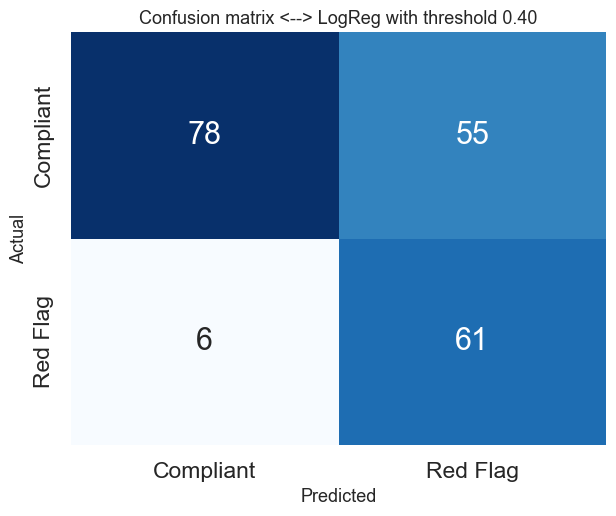

Missed red flags (FN): 6  |  Over-flagged (FP): 55
Miss rate: 9.0%


In [48]:
cm = confusion_matrix(y_test_lr, y_pred_040)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Compliant", "Red Flag"],
            yticklabels=["Compliant", "Red Flag"],
            ax=ax, annot_kws={"size": 22})
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title("Confusion matrix <--> LogReg with threshold 0.40", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Missed red flags (FN): {fn}  |  Over-flagged (FP): {fp}")
print(f"Miss rate: {fn/(fn+tp)*100:.1f}%")

In [49]:
# Compare the three operating points on the same primary model
rows = []
for t in [0.50, 0.45, 0.40]:
    yp = (proba_lr >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_lr, yp).ravel()
    rows.append({
        "threshold": t,
        "recall":    round(recall_score(y_test_lr, yp), 3),
        "precision": round(precision_score(y_test_lr, yp), 3),
        "f1":        round(f1_score(y_test_lr, yp), 3),
        "FN": fn, "FP": fp,
    })
compare_thr = pd.DataFrame(rows)
print(compare_thr.to_string(index=False))

 threshold  recall  precision    f1  FN  FP
      0.50   0.731      0.803 0.766  18  12
      0.45   0.851      0.671 0.750  10  28
      0.40   0.910      0.526 0.667   6  55


**Interpretation.**

| Threshold | Recall | Precision | FN | FP |
| --- | --- | --- | --- | --- |
| 0.50 (default) | 0.731 | 0.803 | 18 | 12 |
| **0.45 (shipped)** | **0.851** | **0.671** | **10** | **28** |
| 0.40 (this test) | 0.910 | 0.526 | 6 | 55 |

Dropping to 0.40 catches almost everything (only **6** missed violations, recall 0.910). As a result, precision drops to 0.526. The model now raises **55** false alarms.

---

# Final Conclusion: Goal 2 - **Update Version 2**

This notebook covers Goal 2 end to end on the **Version-2, marker-free dataset**: a primary baseline, an XGBoost alternative, 5-fold cross-validation, a dense-embedding experiment, and a decision-threshold sensitivity test - each core model with its own risk and fairness analysis.

### 1. The models compared

Test set: 200 proposals, 67 of them Red Flags.

| Model | Recall | Precision | F1 | ROC-AUC | 5-fold CV recall |
| --- | --- | --- | --- | --- | --- |
| Majority (trivial) | 0.000 | 0.000 | 0.000 | - | - |
| Keyword rules | 0.090 | 1.000 | 0.164 | - | - |
| **TF-IDF + Logistic Regression (primary, 0.45)** | **0.851** | **0.671** | **0.750** | **0.901** | **0.937** |
| TF-IDF + Multinomial NB (comparison) | 0.403 | 0.964 | 0.568 | 0.896 | - |
| TF-IDF + XGBoost (alternative, 0.50) | 0.746 | 0.909 | 0.820 | 0.928 | 0.823 |
| BGE-small embeddings + XGBoost (experiment) | 0.507 | 0.667 | 0.576 | 0.786 | - |

**Recall is the priority metric - a missed violation is more costly than a false alarm - so 0.45 stays the operating point, with 0.40 held in reserve if a risk assessment rules that no violation may be missed.**

### 2. Why Logistic Regression is the prefered primary model

On the marker-free data the case is clearer than in Version 1: **TF-IDF + Logistic Regression wins the cross-validation on recall (0.937 vs 0.823, a 0.114 gap)**, while XGBoost wins F1 (0.833 vs 0.735) and precision by flagging more conservatively. We prefer Logistic Regression because:

- It returns the trigger words behind each decision through its linear weights (`top_terms`) - useful for **XAI** and for justifying the agent.
- Linear weights are reproducible and human-readable, matching the record-keeping and oversight duties (for example EU AI Act, Art. 12 and Art. 14).
- Its higher recall matches the recall-first risk posture.

At the 0.45 operating point the primary model misses **10 of 67** violations and over-flags **28** compliant proposals (precision 0.671). Part 5 tests the opposite direction: pushing the threshold down to 0.40 lifts recall to **0.910** (only 6 missed violations) but drops precision to 0.526 with **55** false alarms; raising it to 0.50 gives recall 0.731 / precision 0.803 (18 missed). So **0.45** is the balanced operating point. In Version 1 the default 0.50 reached precision 1.000 - that was the template shortcut, which the marker-free data removes.

### 3. What the model catches (recall per policy)

Four of the nine policies reach recall 1.000 (RAI-01, RAI-02, RAI-06, RAI-07). The weakest are **RAI-08 Data Minimization (0.722)**, **RAI-03 Fairness (0.818)** and **RAI-05 Prohibited Purpose (0.882)** - the policies whose violations are phrased most diversely in the new data.

### 4. Risk

Eight risks were rated on likelihood x impact. The act-first cluster is **R1 false negatives, R4 synthetic-data / shortcut learning, and R5 drift**, each with a repeatable test. The **R4** test on the primary model now shows recall **1.000 on grounded (real NFR)** red flags but **0.773 on synthetic** ones, a gap of **0.227**. The model handles the real, grounded requirements perfectly and still leans on wording for the synthetic cases - so the shortcut risk is reduced but not gone, and R4 stays an active test. On XGBoost the same test gives grounded 0.870 / synthetic 0.682, a gap of 0.188.

### 5. Fairness (on both models)

Fairness is procedural: the "individuals" are proposals, so we ask whether the Sentinel enforces the rules equally across groups. For the primary Logistic Regression the equalized-odds TPR gaps are **0.039 (issue_type)**, **0.308 (ai_method)** and **0.227 (grounded_flag)**. The ai_method gap is the largest but rests on very small subgroups (as few as 4 positive cases per method), so it is a monitoring flag rather than a proven bias. XGBoost shows a comparable pattern (0.086 / 0.400 / 0.188).